#  EuroSAT — Exploratory Data Analysis
**2nd Assignment — Deep Learning for Computer Vision**

EuroSAT is a dataset based on Sentinel-2 satellite imagery covering 13 spectral bands and consisting of 10 classes with 27,000 labeled and geo-referenced samples.

**Classes:** AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River, SeaLake



## 0. Install & Import Dependencies

In [1]:
# Install if needed (Colab usually has these)
!pip install torch torchvision matplotlib seaborn scikit-learn -q

In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import EuroSAT

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from PIL import Image

import os
import random

# Reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

print(f'PyTorch version: {torch.__version__}')
print(f'Torchvision version: {torchvision.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128
CUDA available: False


## 1. Load the Dataset

In [3]:
# Minimal transform just to load images as tensors for EDA
basic_transform = transforms.Compose([
    transforms.ToTensor()
])

# Download and load EuroSAT (RGB version, ~90MB)
dataset = EuroSAT(root='./data', transform=basic_transform, download=True)

# Class names
CLASS_NAMES = dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f'Total samples: {len(dataset)}')
print(f'Number of classes: {NUM_CLASSES}')
print(f'Classes: {CLASS_NAMES}')

100%|██████████| 94.3M/94.3M [00:02<00:00, 43.4MB/s]


Total samples: 27000
Number of classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## 2. Class Distribution

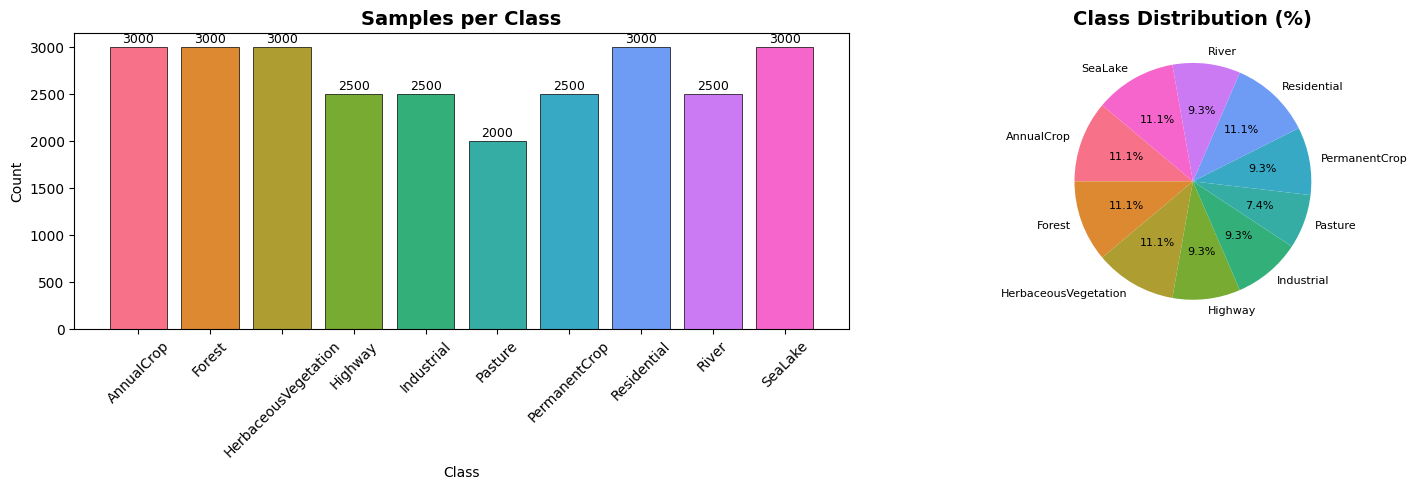


📊 Class Balance Analysis:
  Min samples: 2000 | Max samples: 3000
  Imbalance ratio: 1.50x
  → Dataset is imbalanced — consider weighting


In [4]:
# Count samples per class
labels = [dataset[i][1] for i in range(len(dataset))]
class_counts = Counter(labels)
counts = [class_counts[i] for i in range(NUM_CLASSES)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart
colors = sns.color_palette('husl', NUM_CLASSES)
bars = axes[0].bar(CLASS_NAMES, counts, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Samples per Class', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 str(count), ha='center', va='bottom', fontsize=9)

# Pie chart
axes[1].pie(counts, labels=CLASS_NAMES, colors=colors, autopct='%1.1f%%',
            startangle=140, textprops={'fontsize': 8})
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Class Balance Analysis:')
print(f'  Min samples: {min(counts)} | Max samples: {max(counts)}')
print(f'  Imbalance ratio: {max(counts)/min(counts):.2f}x')
print(f'  → Dataset is {"fairly balanced" if max(counts)/min(counts) < 1.5 else "imbalanced — consider weighting"}')

## 3. Visual Exploration — Sample Images per Class

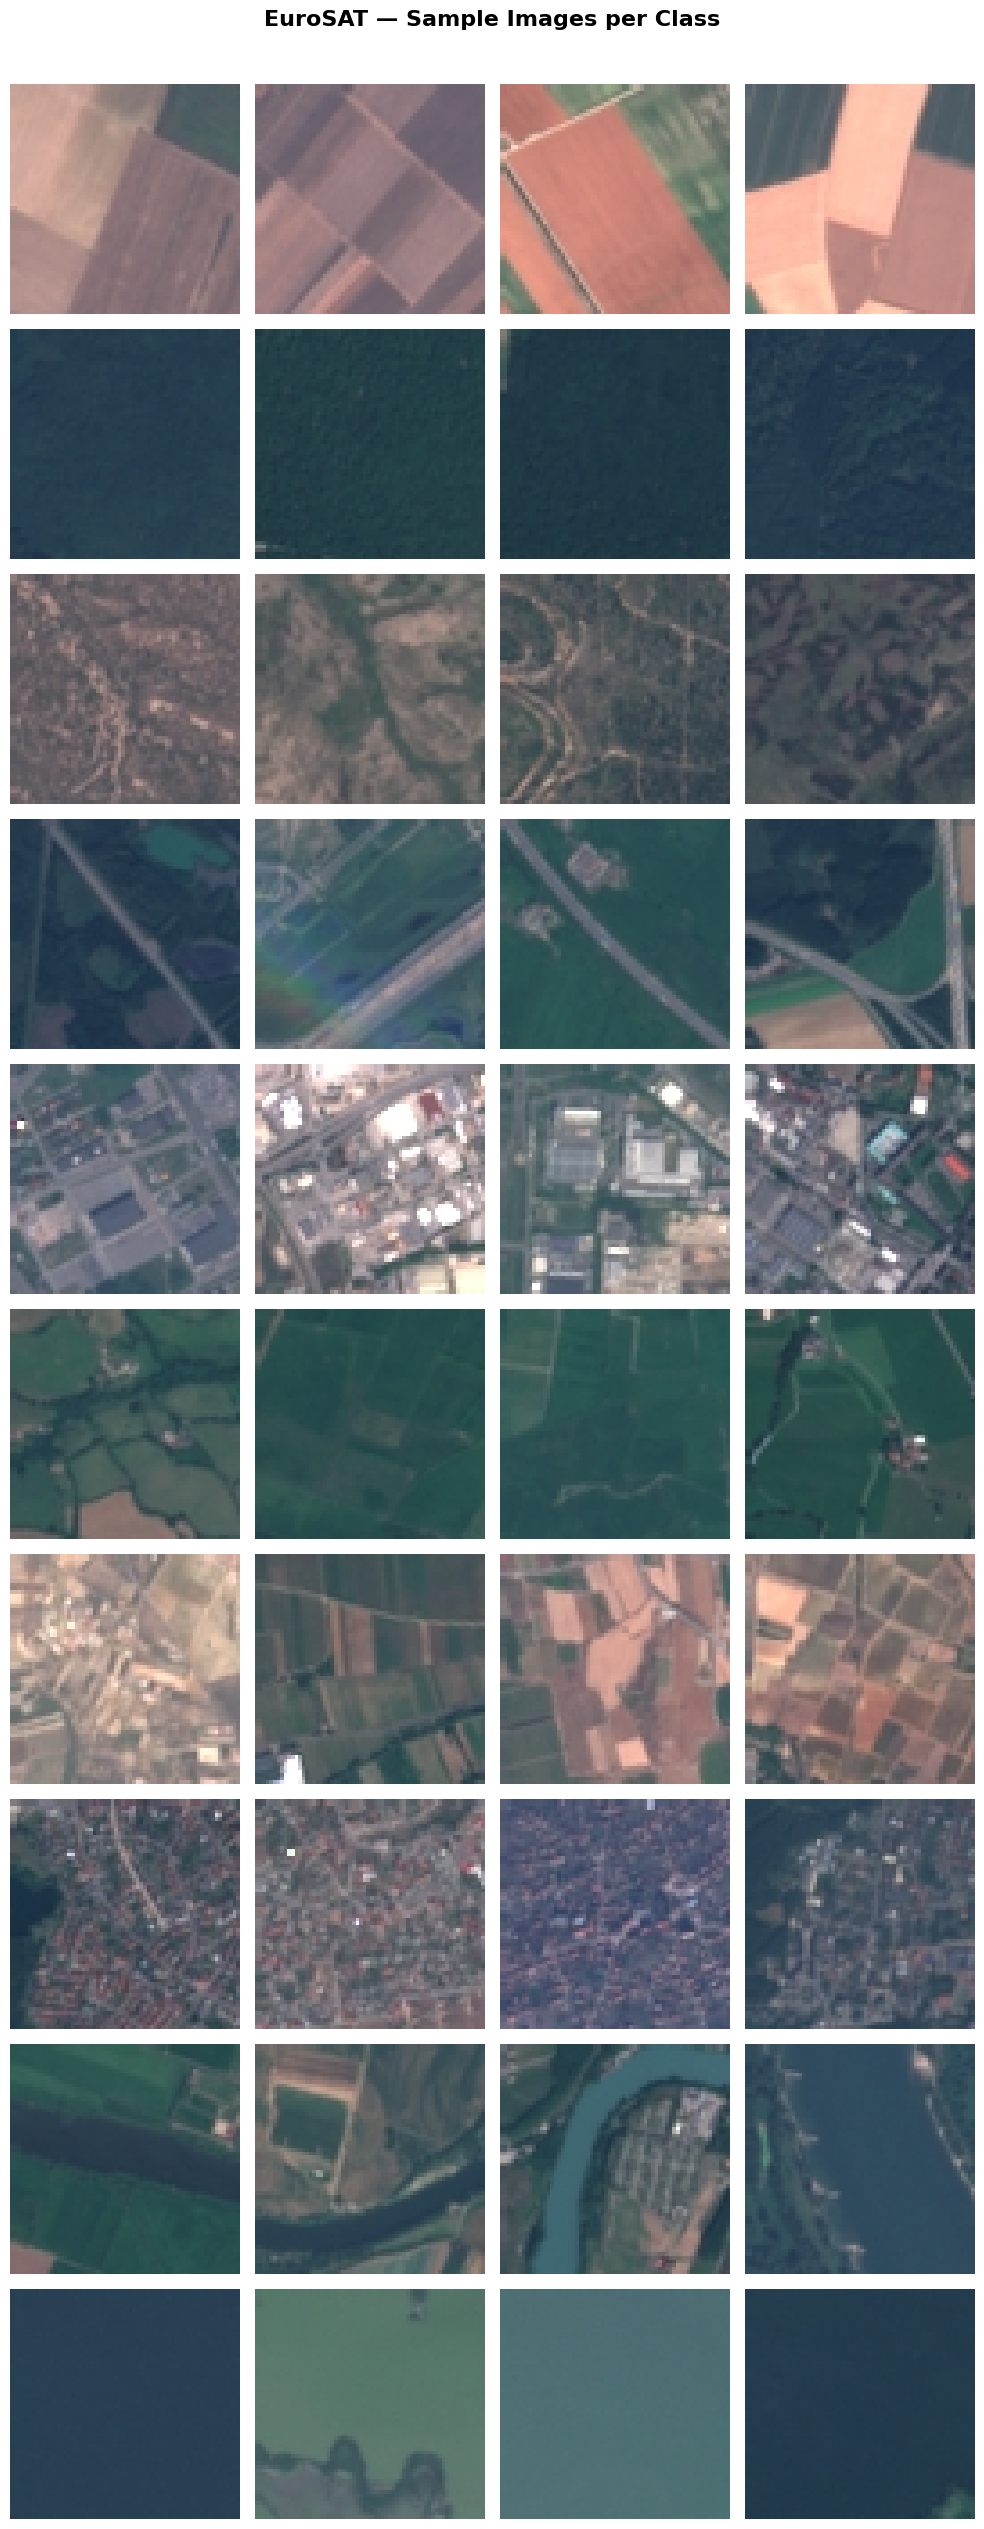

In [5]:
# Get indices grouped by class
class_indices = {i: [] for i in range(NUM_CLASSES)}
for idx, label in enumerate(labels):
    class_indices[label].append(idx)

# Show 4 samples per class
N_SAMPLES = 4
fig, axes = plt.subplots(NUM_CLASSES, N_SAMPLES, figsize=(N_SAMPLES*2.5, NUM_CLASSES*2.5))
fig.suptitle('EuroSAT — Sample Images per Class', fontsize=16, fontweight='bold', y=1.01)

for class_idx, class_name in enumerate(CLASS_NAMES):
    sample_indices = random.sample(class_indices[class_idx], N_SAMPLES)
    for col, img_idx in enumerate(sample_indices):
        img_tensor, _ = dataset[img_idx]
        img_np = img_tensor.permute(1, 2, 0).numpy()
        img_np = np.clip(img_np, 0, 1)
        axes[class_idx][col].imshow(img_np)
        axes[class_idx][col].axis('off')
        if col == 0:
            axes[class_idx][col].set_ylabel(class_name, fontsize=9,
                                             rotation=0, labelpad=60, va='center')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Image Properties Analysis

In [6]:
# Check image dimensions and format
sample_img, sample_label = dataset[0]

print('📐 Image Properties:')
print(f'  Shape (C, H, W): {sample_img.shape}')
print(f'  Height: {sample_img.shape[1]}px | Width: {sample_img.shape[2]}px')
print(f'  Channels: {sample_img.shape[0]} (RGB)')
print(f'  Dtype: {sample_img.dtype}')
print(f'  Value range: [{sample_img.min():.3f}, {sample_img.max():.3f}]')

📐 Image Properties:
  Shape (C, H, W): torch.Size([3, 64, 64])
  Height: 64px | Width: 64px
  Channels: 3 (RGB)
  Dtype: torch.float32
  Value range: [0.322, 0.800]


## 5. Pixel Intensity Distribution per Channel

  Red: mean=0.3523, std=0.2004
  Green: mean=0.3845, std=0.1343
  Blue: mean=0.4114, std=0.1141


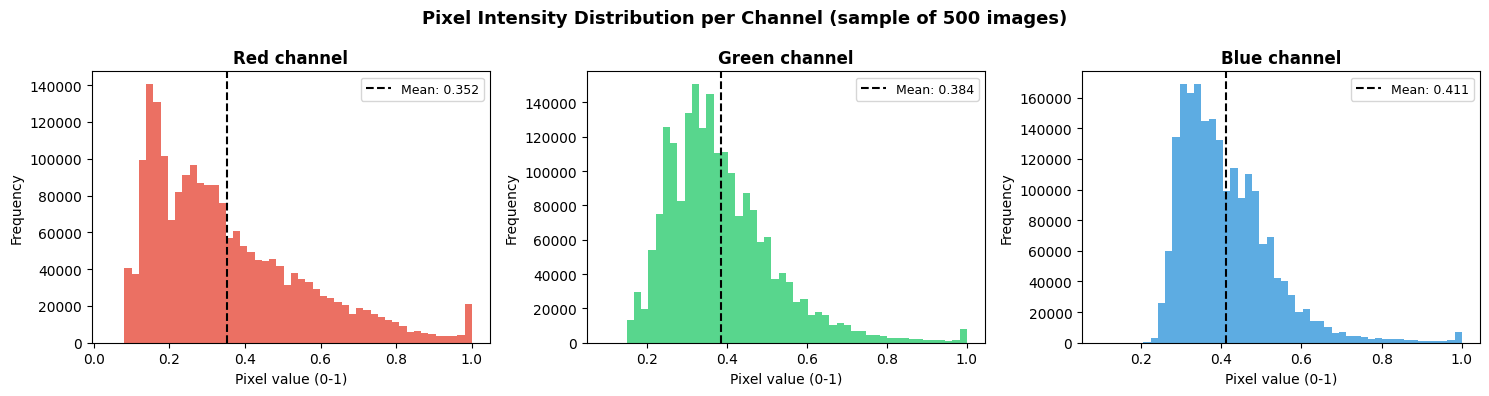

In [7]:
# Sample 500 images for channel statistics (full dataset would be slow)
N_SAMPLE = 500
sample_indices_stats = random.sample(range(len(dataset)), N_SAMPLE)

channel_data = [[], [], []]
for idx in sample_indices_stats:
    img, _ = dataset[idx]
    for c in range(3):
        channel_data[c].extend(img[c].numpy().flatten().tolist())

channel_names = ['Red', 'Green', 'Blue']
channel_colors = ['#e74c3c', '#2ecc71', '#3498db']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'Pixel Intensity Distribution per Channel (sample of {N_SAMPLE} images)',
             fontsize=13, fontweight='bold')

for c in range(3):
    data = np.array(channel_data[c])
    axes[c].hist(data, bins=50, color=channel_colors[c], alpha=0.8, edgecolor='none')
    axes[c].set_title(f'{channel_names[c]} channel', fontweight='bold')
    axes[c].set_xlabel('Pixel value (0-1)')
    axes[c].set_ylabel('Frequency')
    axes[c].axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Mean: {data.mean():.3f}')
    axes[c].legend(fontsize=9)
    print(f'  {channel_names[c]}: mean={data.mean():.4f}, std={data.std():.4f}')

plt.tight_layout()
plt.savefig('channel_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Per-Class Mean Image (Visual Fingerprint)

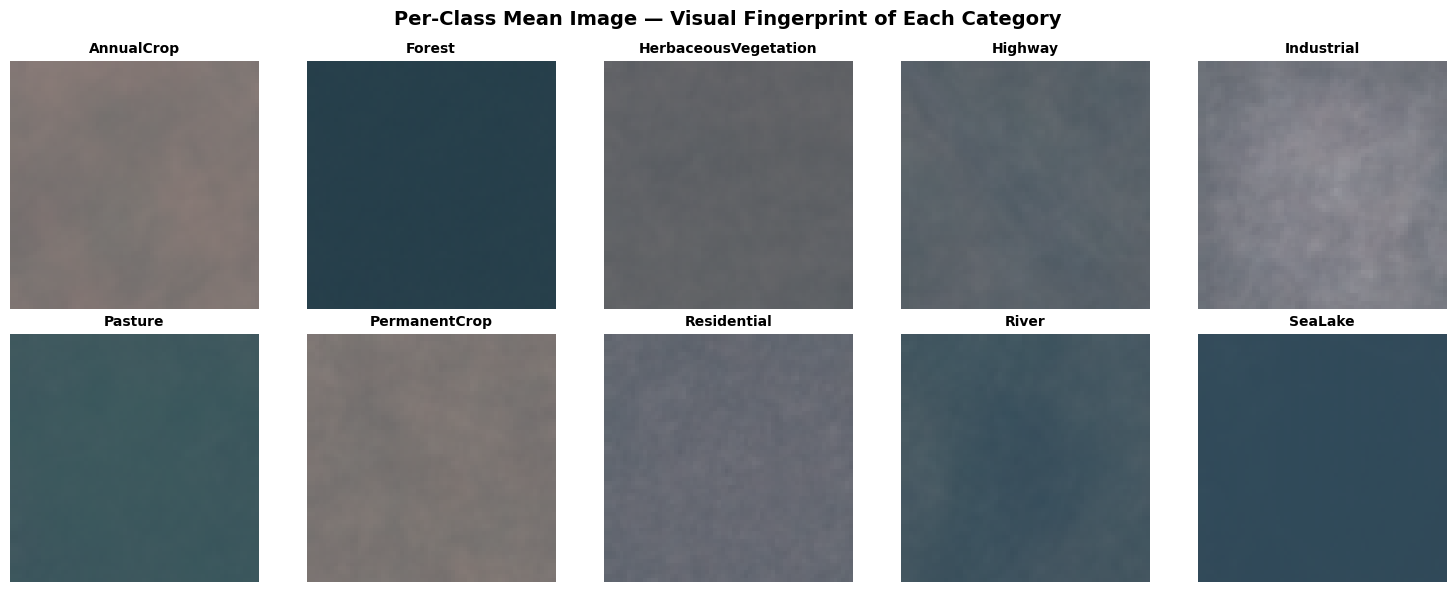

💡 The mean images reveal the dominant color/texture signature of each class.
   Classes that look very different here will be easier for the model to separate.


In [8]:
# Compute mean image per class (using 100 samples per class)
N_PER_CLASS = 100
mean_images = {}

for class_idx, class_name in enumerate(CLASS_NAMES):
    idxs = random.sample(class_indices[class_idx], N_PER_CLASS)
    imgs = torch.stack([dataset[i][0] for i in idxs])  # (N, C, H, W)
    mean_images[class_name] = imgs.mean(dim=0).permute(1, 2, 0).numpy()

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Per-Class Mean Image — Visual Fingerprint of Each Category',
             fontsize=14, fontweight='bold')

for idx, (class_name, mean_img) in enumerate(mean_images.items()):
    ax = axes[idx // 5][idx % 5]
    ax.imshow(np.clip(mean_img, 0, 1))
    ax.set_title(class_name, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig('mean_images_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 The mean images reveal the dominant color/texture signature of each class.')
print('   Classes that look very different here will be easier for the model to separate.')

## 7. Train / Validation / Test Split

In [9]:
from torch.utils.data import random_split

total = len(dataset)
train_size = int(0.7 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print('📦 Dataset Split:')
print(f'  Total:      {total:>6,} images')
print(f'  Train:      {len(train_ds):>6,} images ({len(train_ds)/total*100:.1f}%)')
print(f'  Validation: {len(val_ds):>6,} images ({len(val_ds)/total*100:.1f}%)')
print(f'  Test:       {len(test_ds):>6,} images ({len(test_ds)/total*100:.1f}%)')

📦 Dataset Split:
  Total:      27,000 images
  Train:      18,900 images (70.0%)
  Validation:  4,050 images (15.0%)
  Test:        4,050 images (15.0%)


## 8. Dataset Mean & Std (for Normalization)

In [11]:
# Compute dataset-level mean and std for normalization
# We use a subset for speed — use full train split for production
loader = torch.utils.data.DataLoader(train_ds, batch_size=64, shuffle=False, num_workers=2)

mean = torch.zeros(3)
std  = torch.zeros(3)
n_batches = 0

for imgs, _ in loader:
    for c in range(3):
        mean[c] += imgs[:, c, :, :].mean()
        std[c]  += imgs[:, c, :, :].std()
    n_batches += 1

mean /= n_batches
std  /= n_batches

print('📏 Normalization statistics:')
print(f'  mean = ({mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f})')
print(f'  std  = ({std[0]:.4f},  {std[1]:.4f},  {std[2]:.4f})')
print()
print('Use in transforms.Normalize():')
print(f'  transforms.Normalize(mean=[{mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}],')
print(f'                       std=[{std[0]:.4f}, {std[1]:.4f}, {std[2]:.4f}])')

📏 Normalization statistics:
  mean = (0.3437, 0.3798, 0.4076)
  std  = (0.2008,  0.1360,  0.1148)

Use in transforms.Normalize():
  transforms.Normalize(mean=[0.3437, 0.3798, 0.4076],
                       std=[0.2008, 0.1360, 0.1148])


## 9. EDA Summary & Key Takeaways

In [12]:
print('=' * 55)
print('          EuroSAT EDA — SUMMARY')
print('=' * 55)
print(f'  Total images    : {len(dataset):,}')
print(f'  Classes         : {NUM_CLASSES}')
print(f'  Image size      : {sample_img.shape[1]}x{sample_img.shape[2]}px (RGB)')
print(f'  Imbalance ratio : {max(counts)/min(counts):.2f}x')
print(f'  Train / Val / Test : {len(train_ds):,} / {len(val_ds):,} / {len(test_ds):,}')
print()
print('Key insights for modeling:')
print('  ✅ Dataset is fairly balanced — standard CrossEntropyLoss is fine')
print('  ✅ Images are small (64x64) — light CNN is enough, no need to resize')
print('  ✅ Satellite imagery is very different from ImageNet')
print('     → interesting to see how much transfer learning still helps')
print('  ⚠️  Some classes are visually similar (e.g. AnnualCrop vs PermanentCrop)')
print('     → good challenge to mention in the defense')
print('=' * 55)

          EuroSAT EDA — SUMMARY
  Total images    : 27,000
  Classes         : 10
  Image size      : 64x64px (RGB)
  Imbalance ratio : 1.50x
  Train / Val / Test : 18,900 / 4,050 / 4,050

Key insights for modeling:
  ✅ Dataset is fairly balanced — standard CrossEntropyLoss is fine
  ✅ Images are small (64x64) — light CNN is enough, no need to resize
  ✅ Satellite imagery is very different from ImageNet
     → interesting to see how much transfer learning still helps
  ⚠️  Some classes are visually similar (e.g. AnnualCrop vs PermanentCrop)
     → good challenge to mention in the defense
